# Degree-matched random mask counterfactual

This notebook tests whether `MASKED_GLORIA` benefits from assigning learned mask values to **specific interactions**, beyond its degree-dependent attenuation profile.

For every random trial, learned logits are permuted only among edges whose users belong to the same degree group (`1–5`, `6–20`, `21–50`, `51+`). This preserves each group's complete mask distribution—and therefore its mean attenuation—exactly, while breaking the learned edge assignment.

The main comparison is the learned checkpoint against the distribution of degree-matched random permutations.

In [8]:
import os
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path(r"C:\study\Master_papers\Robust MM\CaMuRe")
SRC_ROOT = PROJECT_ROOT / "src"
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "saved"
    / "MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth"
)
OUTPUT_DIR = SRC_ROOT / "degree_matched_random_outputs"

MODEL_NAME = "MASKED_GLORIA"
DATASET_NAME = "book"
N_RANDOM_SEEDS = int(os.environ.get("DMRC_N_RANDOM_SEEDS", "500"))
RANDOM_SEED_START = 1000
REPORT_K = 20
SAVE_OUTPUTS = True

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(CHECKPOINT_PATH)
if N_RANDOM_SEEDS < 2:
    raise ValueError("N_RANDOM_SEEDS must be at least 2.")

os.chdir(PROJECT_ROOT)
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Random trials: {N_RANDOM_SEEDS}")

Checkpoint: C:\study\Master_papers\Robust MM\CaMuRe\saved\MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth
Random trials: 500


## 1. Rebuild the dataset/model and load the checkpoint

The explicit `inter_num` assignment makes this notebook robust to older cached versions of `RecDataset`. The checkpoint loader also remaps two legacy parameter aliases produced by the original training code.

In [9]:
from utils.configurator import Config
from utils.dataset import RecDataset
from utils.dataloader import TrainDataLoader, EvalDataLoader
from utils.utils import get_model, get_trainer, init_seed

# Structural settings must match the checkpoint's training run.
config_dict = {
    "gpu_id": 0,
    "use_gpu": True,
    "fusion": "add",
    "seed": 999,
    "knn_k": 10,
    "n_mm_layers": 1,
    "aggr_mode": "add",
    "reg_weight": 0.01,
    "learning_rate": 0.0001,
    "save_recommended_topk": False,
}

config = Config(
    model=MODEL_NAME,
    dataset=DATASET_NAME,
    config_dict=config_dict,
)
init_seed(config["seed"])

dataset = RecDataset(config)
train_dataset, valid_dataset, test_dataset = dataset.split()

# Defensive fix for kernels that cached an older RecDataset definition.
for split_dataset in (train_dataset, valid_dataset, test_dataset):
    split_dataset.inter_num = len(split_dataset.df)

train_data = TrainDataLoader(
    config,
    train_dataset,
    batch_size=config["train_batch_size"],
    shuffle=True,
)
valid_data = EvalDataLoader(
    config,
    valid_dataset,
    additional_dataset=train_dataset,
    batch_size=config["eval_batch_size"],
)
test_data = EvalDataLoader(
    config,
    test_dataset,
    additional_dataset=train_dataset,
    batch_size=config["eval_batch_size"],
)
train_data.pretrain_setup()

model = get_model(MODEL_NAME)(config, train_data).to(config["device"])

try:
    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=config["device"],
        weights_only=True,
    )
except TypeError:
    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=config["device"],
    )

raw_state_dict = checkpoint.get("state_dict", checkpoint)
state_dict = {
    (key[7:] if key.startswith("module.") else key): value
    for key, value in raw_state_dict.items()
}

# Older checkpoints registered these GCN parameters through aliases
# created during forward(). Remap them to the fresh model's real keys.
legacy_key_map = {
    "full_preference": "full_gcn.preference",
    "mask_preference": "mask_gcn.preference",
}
for old_key, new_key in legacy_key_map.items():
    if old_key in state_dict and new_key not in state_dict:
        state_dict[new_key] = state_dict.pop(old_key)

model.load_state_dict(state_dict, strict=True)
trainer = get_trainer()(config, model)

print(f"Device: {config['device']}")
print(f"Users/items: {model.n_users:,}/{model.n_items:,}")
print(f"Training edges: {model.num_interactions:,}")
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")

Loading pre-extracted features from C:\study\Master_papers\Robust MM\CaMuRe\data\book\text_feat.npy
number of users: 11000, number of items: 9332
Device: cuda
Users/items: 11,000/9,332
Training edges: 120,464
Loaded checkpoint: MASKED_GLORIA-book-seed999-Aug-12-2026-13-46-25.pth


## 2. High-precision evaluation helpers

`MASKED_GLORIA.full_sort_predict()` uses a cached `result_embed`. The helper below recomputes it after every mask permutation. It also avoids the evaluator's default four-decimal rounding, which is too coarse for a permutation test.

In [10]:
@torch.no_grad()
def recompute_result_embeddings(current_model):
    current_model.eval()
    device = current_model.mask_logits.device
    dummy_user = torch.zeros(1, dtype=torch.long, device=device)
    dummy_positive = torch.zeros(1, dtype=torch.long, device=device)
    dummy_negative = torch.zeros(1, dtype=torch.long, device=device)
    current_model.forward((dummy_user, dummy_positive, dummy_negative))


@torch.no_grad()
def evaluate_current_mask(current_model, current_trainer, eval_data):
    recompute_result_embeddings(current_model)
    current_model.eval()

    # Ensure a clean iterator even if a previous evaluation was interrupted.
    eval_data.pr = 0
    eval_data.inter_pr = 0

    topk_batches = []
    max_k = max(current_trainer.config["topk"])

    for batched_data in eval_data:
        scores = current_model.full_sort_predict(batched_data)
        masked_items = batched_data[1]
        scores[masked_items[0], masked_items[1]] = -1e10
        _, topk_index = torch.topk(scores, max_k, dim=-1)
        topk_batches.append(topk_index)

    topk_index = torch.cat(topk_batches, dim=0).cpu().numpy()
    positive_items = eval_data.get_eval_items()
    positive_lengths = eval_data.get_eval_len_list()

    relevance = np.asarray([
        [item in positives for item in recommendations]
        for positives, recommendations in zip(positive_items, topk_index)
    ])

    evaluator = current_trainer.evaluator
    metric_arrays = evaluator._calculate_metrics(
        positive_lengths,
        relevance,
    )

    result = {}
    for metric_name, values in zip(evaluator.metrics, metric_arrays):
        for k in evaluator.topk:
            result[f"{metric_name}@{k}"] = float(values[k - 1])

    return result

## 3. Build degree strata and inspect learned attenuation

In [11]:
n_edges = model.num_interactions
edge_users = model.edge_index[0, :n_edges].detach().cpu()
user_degree = torch.bincount(edge_users, minlength=model.n_users)
edge_user_degree = user_degree[edge_users]

degree_group = torch.full((n_edges,), -1, dtype=torch.long)
degree_group[(edge_user_degree >= 1) & (edge_user_degree <= 5)] = 0
degree_group[(edge_user_degree >= 6) & (edge_user_degree <= 20)] = 1
degree_group[(edge_user_degree >= 21) & (edge_user_degree <= 50)] = 2
degree_group[edge_user_degree >= 51] = 3

if (degree_group < 0).any():
    raise RuntimeError("At least one training edge was not assigned to a degree group.")

degree_group_names = {
    0: "1-5",
    1: "6-20",
    2: "21-50",
    3: "51+",
}

learned_logits = model.mask_logits.detach().clone()
learned_mask = torch.sigmoid(learned_logits)


def summarize_attenuation(mask_values, label):
    rows = []
    for group_id, group_name in degree_group_names.items():
        indices = torch.where(degree_group == group_id)[0]
        group_mask = mask_values[indices.to(mask_values.device)]
        group_drop = 1.0 - group_mask
        rows.append({
            "condition": label,
            "degree_group": group_name,
            "n_edges": int(indices.numel()),
            "mean_mask": float(group_mask.mean().item()),
            "mean_drop": float(group_drop.mean().item()),
            "std_drop": float(group_drop.std().item()),
        })
    return pd.DataFrame(rows)

learned_attenuation = summarize_attenuation(learned_mask, "Learned")
display(learned_attenuation.set_index("degree_group").round(6))

,condition,n_edges,mean_mask,mean_drop,std_drop
degree_group,,,,,
1-5,Learned,14080,0.972711,0.027288,0.042048
6-20,Learned,59910,0.960009,0.039991,0.063684
21-50,Learned,27144,0.934294,0.065706,0.099845
51+,Learned,19330,0.907739,0.092261,0.145332


## 4. Generate an exactly degree-matched random mask

Permuting logits inside each stratum preserves all values in that stratum exactly. Consequently, the learned and randomized mean attenuation should differ only by floating-point roundoff.

In [20]:
def make_per_user_random_logits(
    source_logits,
    edge_users,
    seed
):
    randomized_logits = source_logits.clone()

    generator = torch.Generator(device="cpu")
    generator.manual_seed(int(seed))

    edge_users_cpu = edge_users.detach().cpu()

    for user_id in torch.unique(edge_users_cpu).tolist():

        target_indices_cpu = torch.where(
            edge_users_cpu == user_id
        )[0]

        # degree 0 or 1 cannot really be shuffled
        if target_indices_cpu.numel() <= 1:
            continue

        permutation = torch.randperm(
            target_indices_cpu.numel(),
            generator=generator,
        )

        source_indices_cpu = (
            target_indices_cpu[permutation]
        )

        target_indices = target_indices_cpu.to(
            source_logits.device
        )

        source_indices = source_indices_cpu.to(
            source_logits.device
        )

        randomized_logits[target_indices] = (
            source_logits[source_indices]
        )

    return randomized_logits

In [24]:
def verify_per_user_shuffle(
    learned_logits,
    randomized_logits,
    edge_users,
    atol=1e-7
):
    edge_users_cpu = edge_users.detach().cpu()

    for user_id in torch.unique(edge_users_cpu).tolist():

        idx_cpu = torch.where(
            edge_users_cpu == user_id
        )[0]

        idx = idx_cpu.to(
            learned_logits.device
        )

        learned_u = torch.sort(
            learned_logits[idx]
        ).values

        random_u = torch.sort(
            randomized_logits[idx]
        ).values

        if not torch.allclose(
            learned_u,
            random_u,
            atol=atol,
            rtol=0
        ):
            raise AssertionError(
                f"Per-user matching failed "
                f"for user {user_id}"
            )

    print(
        "Per-user permutation check PASSED."
    )

Per-user permutation check PASSED.


,n_edges,mean_drop_learned,mean_drop_random,absolute_mean_drop_error
degree_group,,,,
1-5,14080,0.027288,0.027288,0.000000e+00
6-20,59910,0.039991,0.039991,7.500000e-09
21-50,27144,0.065706,0.065706,0.000000e+00
51+,19330,0.092261,0.092261,0.000000e+00


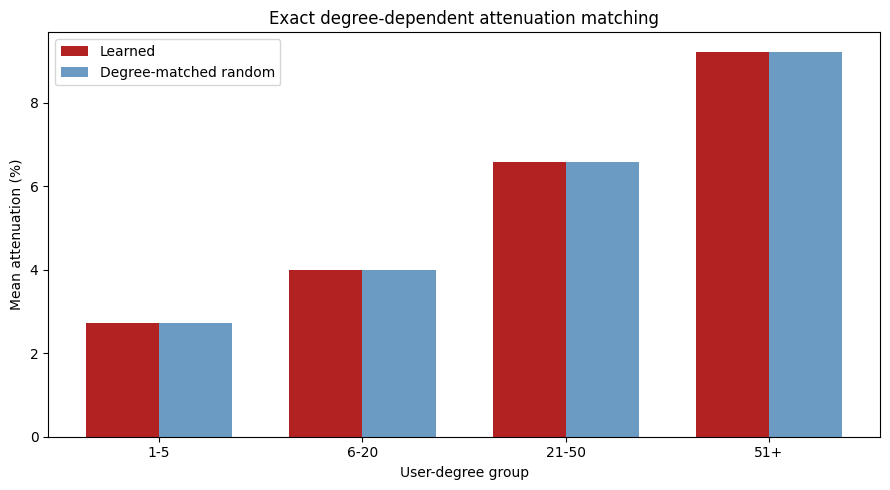

In [25]:
def make_degree_matched_random_logits(source_logits, strata, seed):
    randomized_logits = source_logits.clone()
    generator = torch.Generator(device="cpu")
    generator.manual_seed(int(seed))

    for group_id in sorted(strata.unique().tolist()):
        target_indices_cpu = torch.where(strata == group_id)[0]
        permutation = torch.randperm(
            target_indices_cpu.numel(),
            generator=generator,
        )
        source_indices_cpu = target_indices_cpu[permutation]
        target_indices = target_indices_cpu.to(source_logits.device)
        source_indices = source_indices_cpu.to(source_logits.device)
        randomized_logits[target_indices] = source_logits[source_indices]

    return randomized_logits


# example_random_logits = make_degree_matched_random_logits(
#     learned_logits,
#     degree_group,
#     seed=RANDOM_SEED_START,
# )

# example_random_logits =  make_per_user_random_logits(
#     learned_logits,
#     degree_group,
#     seed=RANDOM_SEED_START,
# )

example_random_logits = make_per_user_random_logits(
    learned_logits,
    edge_users,
    seed=RANDOM_SEED_START,
)

verify_per_user_shuffle(
    learned_logits,
    example_random_logits,
    edge_users
)
example_random_mask = torch.sigmoid(example_random_logits)
random_attenuation = summarize_attenuation(example_random_mask, "Degree-random")

attenuation_check = learned_attenuation.merge(
    random_attenuation,
    on=["degree_group", "n_edges"],
    suffixes=("_learned", "_random"),
)
attenuation_check["absolute_mean_drop_error"] = (
    attenuation_check["mean_drop_learned"]
    - attenuation_check["mean_drop_random"]
).abs()

max_matching_error = attenuation_check["absolute_mean_drop_error"].max()
if max_matching_error > 1e-7:
    raise AssertionError(f"Degree matching failed: max error={max_matching_error}")

display(
    attenuation_check[[
        "degree_group",
        "n_edges",
        "mean_drop_learned",
        "mean_drop_random",
        "absolute_mean_drop_error",
    ]].set_index("degree_group").round(10)
)

x = np.arange(len(attenuation_check))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    x - width / 2,
    100 * attenuation_check["mean_drop_learned"],
    width,
    label="Learned",
    color="firebrick",
)
ax.bar(
    x + width / 2,
    100 * attenuation_check["mean_drop_random"],
    width,
    label="Degree-matched random",
    color="steelblue",
    alpha=0.8,
)
ax.set_xticks(x)
ax.set_xticklabels(attenuation_check["degree_group"])
ax.set_xlabel("User-degree group")
ax.set_ylabel("Mean attenuation (%)")
ax.set_title("Exact degree-dependent attenuation matching")
ax.legend()
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUTPUT_DIR / "attenuation_matching.png", dpi=200, bbox_inches="tight")
    attenuation_check.to_csv(OUTPUT_DIR / "attenuation_matching.csv", index=False)
plt.show()

## 5. Evaluate learned mask and random counterfactuals

The `finally` block always restores the learned logits, even if an evaluation fails. For a quick smoke test, set the environment variable `DMRC_N_RANDOM_SEEDS=2`; use at least 50–100 trials for the final paper table.

In [13]:
with torch.no_grad():
    model.mask_logits.copy_(learned_logits)

evaluation_start = perf_counter()
learned_result = evaluate_current_mask(model, trainer, test_data)
print("Learned-mask performance:")
display(pd.Series(learned_result, name="learned").to_frame())

random_results = []
random_seeds = range(
    RANDOM_SEED_START,
    RANDOM_SEED_START + N_RANDOM_SEEDS,
)

try:
    for trial_index, random_seed in enumerate(random_seeds, start=1):
        randomized_logits = make_degree_matched_random_logits(
            learned_logits,
            degree_group,
            seed=random_seed,
        )
        with torch.no_grad():
            model.mask_logits.copy_(randomized_logits)

        trial_result = evaluate_current_mask(model, trainer, test_data)
        random_results.append({"seed": random_seed, **trial_result})
        elapsed = perf_counter() - evaluation_start
        print(
            f"Trial {trial_index:>3}/{N_RANDOM_SEEDS} complete "
            f"(elapsed {elapsed:.1f}s)"
        )
finally:
    with torch.no_grad():
        model.mask_logits.copy_(learned_logits)
    recompute_result_embeddings(model)

random_results = pd.DataFrame(random_results)
if len(random_results) != N_RANDOM_SEEDS:
    raise RuntimeError("Not all random trials completed.")

print(f"Completed in {perf_counter() - evaluation_start:.1f}s")
display(random_results.head())
if SAVE_OUTPUTS:
    random_results.to_csv(OUTPUT_DIR / "random_trial_metrics.csv", index=False)

Learned-mask performance:


,learned
recall@5,0.085705
recall@10,0.126795
recall@15,0.153992
recall@20,0.176757
ndcg@5,0.085537
ndcg@10,0.099084
ndcg@15,0.108167
ndcg@20,0.115520
precision@5,0.056917
precision@10,0.043621


Trial   1/500 complete (elapsed 2.1s)
Trial   2/500 complete (elapsed 3.2s)
Trial   3/500 complete (elapsed 4.2s)
Trial   4/500 complete (elapsed 5.1s)
Trial   5/500 complete (elapsed 6.2s)
Trial   6/500 complete (elapsed 7.5s)
Trial   7/500 complete (elapsed 9.4s)
Trial   8/500 complete (elapsed 11.0s)
Trial   9/500 complete (elapsed 12.4s)
Trial  10/500 complete (elapsed 14.1s)
Trial  11/500 complete (elapsed 15.7s)
Trial  12/500 complete (elapsed 17.1s)
Trial  13/500 complete (elapsed 18.8s)
Trial  14/500 complete (elapsed 20.2s)
Trial  15/500 complete (elapsed 21.7s)
Trial  16/500 complete (elapsed 23.0s)
Trial  17/500 complete (elapsed 23.9s)
Trial  18/500 complete (elapsed 25.1s)
Trial  19/500 complete (elapsed 26.3s)
Trial  20/500 complete (elapsed 27.6s)
Trial  21/500 complete (elapsed 28.5s)
Trial  22/500 complete (elapsed 29.6s)
Trial  23/500 complete (elapsed 30.5s)
Trial  24/500 complete (elapsed 31.6s)
Trial  25/500 complete (elapsed 32.5s)
Trial  26/500 complete (elapsed 

,seed,recall@5,recall@10,recall@15,recall@20,ndcg@5,ndcg@10,ndcg@15,ndcg@20,precision@5,precision@10,precision@15,precision@20,map@5,map@10,map@15,map@20
0,1000,0.084880,0.126120,0.153507,0.177547,0.084824,0.098462,0.107601,0.115305,0.056511,0.043428,0.036281,0.032023,0.055891,0.058797,0.060987,0.062759
1,1001,0.084569,0.125613,0.153646,0.177511,0.084658,0.098286,0.107658,0.115326,0.056308,0.043286,0.036254,0.032018,0.055824,0.058745,0.061030,0.062801
2,1002,0.085009,0.126001,0.153517,0.177281,0.085124,0.098606,0.107868,0.115434,0.056572,0.043327,0.036356,0.031968,0.056164,0.058993,0.061229,0.062982
3,1003,0.084477,0.126703,0.154196,0.177924,0.084825,0.098875,0.108124,0.115709,0.056227,0.043469,0.036423,0.032099,0.056047,0.059120,0.061356,0.063126
4,1004,0.084635,0.125946,0.153797,0.178007,0.084979,0.098548,0.107952,0.115711,0.056450,0.043174,0.036315,0.032084,0.056126,0.059014,0.061311,0.063116


## 6. Permutation-test summary and plots

For ranking metrics, larger is better. The one-sided empirical p-value is `(1 + number of random scores >= learned score) / (R + 1)`.

,learned,random_mean,random_std,random_2.5%,random_97.5%,learned_minus_random,relative_gain_%,fraction_random_at_least_learned,empirical_p
metric,,,,,,,,,
recall@5,0.085705,0.085090,0.000232,0.084616,0.085533,0.000615,0.722964,0.002,0.003992
recall@10,0.126795,0.126192,0.000271,0.125654,0.126677,0.000603,0.478002,0.008,0.009980
recall@15,0.153992,0.153577,0.000267,0.153016,0.154078,0.000415,0.269937,0.062,0.063872
recall@20,0.176757,0.177653,0.000280,0.177110,0.178172,-0.000896,-0.504300,1.000,1.000000
ndcg@5,0.085537,0.085130,0.000153,0.084830,0.085429,0.000406,0.477489,0.000,0.001996
ndcg@10,0.099084,0.098679,0.000133,0.098423,0.098962,0.000405,0.410455,0.000,0.001996
ndcg@15,0.108167,0.107860,0.000120,0.107615,0.108083,0.000307,0.284818,0.000,0.001996
ndcg@20,0.115520,0.115577,0.000126,0.115317,0.115820,-0.000057,-0.049479,0.680,0.680639
precision@5,0.056917,0.056582,0.000124,0.056318,0.056795,0.000335,0.592514,0.000,0.001996


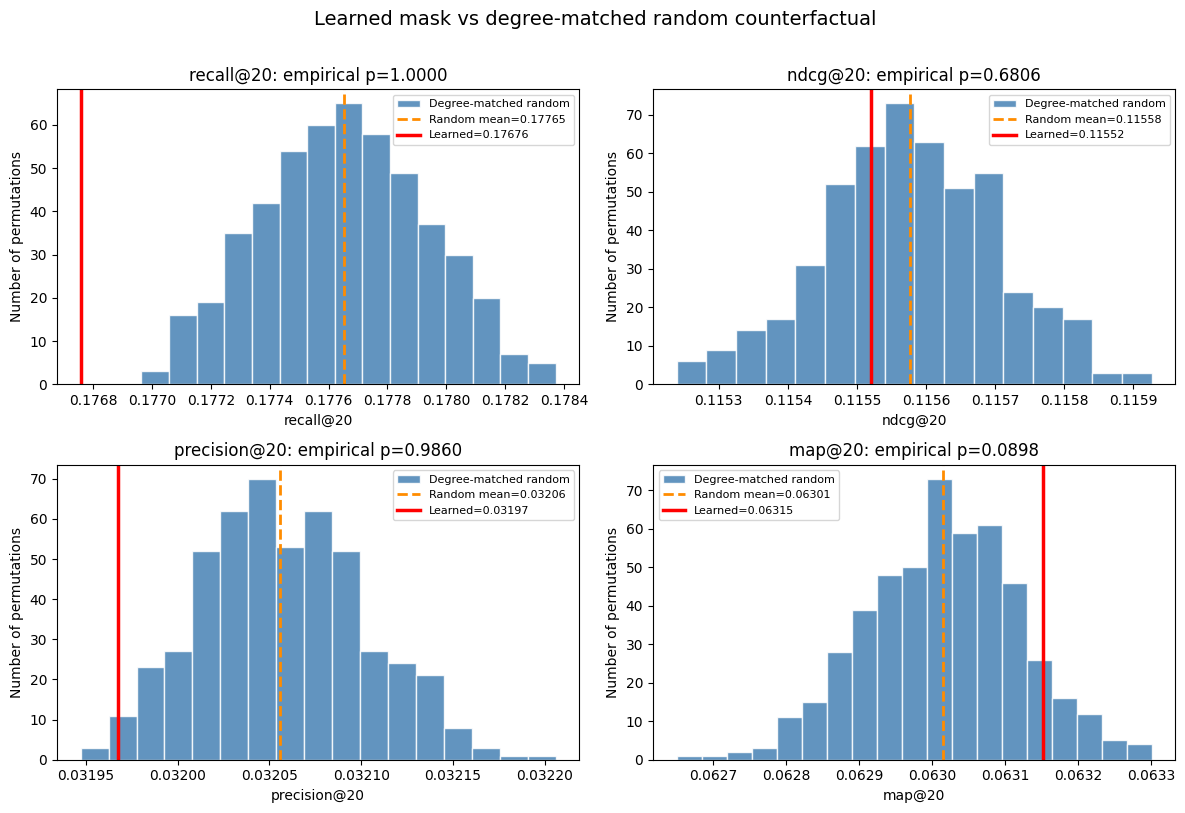

In [14]:
metric_columns = [column for column in random_results.columns if column != "seed"]
summary_rows = []

for metric in metric_columns:
    random_values = random_results[metric].to_numpy(dtype=float)
    learned_value = float(learned_result[metric])
    random_mean = float(random_values.mean())
    random_std = float(random_values.std(ddof=1))
    empirical_p = float(
        (1 + np.sum(random_values >= learned_value))
        / (len(random_values) + 1)
    )

    summary_rows.append({
        "metric": metric,
        "learned": learned_value,
        "random_mean": random_mean,
        "random_std": random_std,
        "random_2.5%": float(np.quantile(random_values, 0.025)),
        "random_97.5%": float(np.quantile(random_values, 0.975)),
        "learned_minus_random": learned_value - random_mean,
        "relative_gain_%": (
            100.0 * (learned_value / random_mean - 1.0)
            if random_mean != 0.0
            else np.nan
        ),
        "fraction_random_at_least_learned": float(
            np.mean(random_values >= learned_value)
        ),
        "empirical_p": empirical_p,
    })

performance_summary = pd.DataFrame(summary_rows).set_index("metric")
display(performance_summary.round(6))
if SAVE_OUTPUTS:
    performance_summary.to_csv(OUTPUT_DIR / "performance_summary.csv")

report_metrics = [
    metric
    for metric in metric_columns
    if metric.endswith(f"@{REPORT_K}")
]
n_columns = 2
n_rows = int(np.ceil(len(report_metrics) / n_columns))
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(12, 4 * n_rows),
)
axes = np.asarray(axes).reshape(-1)

for ax, metric in zip(axes, report_metrics):
    random_values = random_results[metric].to_numpy(dtype=float)
    learned_value = float(learned_result[metric])
    empirical_p = float(performance_summary.loc[metric, "empirical_p"])

    ax.hist(
        random_values,
        bins="auto",
        color="steelblue",
        edgecolor="white",
        alpha=0.85,
        label="Degree-matched random",
    )
    ax.axvline(
        random_values.mean(),
        color="darkorange",
        linestyle="--",
        linewidth=2,
        label=f"Random mean={random_values.mean():.5f}",
    )
    ax.axvline(
        learned_value,
        color="red",
        linewidth=2.5,
        label=f"Learned={learned_value:.5f}",
    )
    ax.set_xlabel(metric)
    ax.set_ylabel("Number of permutations")
    ax.set_title(f"{metric}: empirical p={empirical_p:.4f}")
    ax.legend(fontsize=8)

for ax in axes[len(report_metrics):]:
    ax.remove()

fig.suptitle(
    "Learned mask vs degree-matched random counterfactual",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUTPUT_DIR / "performance_permutation_test.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
with torch.no_grad():
    model.mask_logits.copy_(learned_logits)

evaluation_start = perf_counter()

learned_result = evaluate_current_mask(
    model,
    trainer,
    test_data
)

print("Learned-mask performance:")
display(
    pd.Series(
        learned_result,
        name="learned"
    ).to_frame()
)


# =========================================================
# PER-USER RANDOMIZATION
# =========================================================

random_results = []
N_RANDOM_SEEDS = 100
random_seeds = range(
    RANDOM_SEED_START,
    RANDOM_SEED_START + N_RANDOM_SEEDS,
)

try:

    for trial_index, random_seed in enumerate(
        random_seeds,
        start=1
    ):

        # IMPORTANT:
        # shuffle only among interactions of SAME user
        randomized_logits = make_per_user_random_logits(
            learned_logits,
            edge_users,
            seed=random_seed,
        )

        with torch.no_grad():
            model.mask_logits.copy_(
                randomized_logits
            )

        trial_result = evaluate_current_mask(
            model,
            trainer,
            test_data
        )

        random_results.append(
            {
                "seed": random_seed,
                **trial_result
            }
        )

        elapsed = (
            perf_counter()
            - evaluation_start
        )

        print(
            f"Trial {trial_index:>3}/"
            f"{N_RANDOM_SEEDS} complete "
            f"(elapsed {elapsed:.1f}s)"
        )

finally:

    with torch.no_grad():
        model.mask_logits.copy_(
            learned_logits
        )

    recompute_result_embeddings(model)


random_results = pd.DataFrame(
    random_results
)

if len(random_results) != N_RANDOM_SEEDS:
    raise RuntimeError(
        "Not all random trials completed."
    )

Learned-mask performance:


,learned
recall@5,0.085705
recall@10,0.126795
recall@15,0.153992
recall@20,0.176757
ndcg@5,0.085537
ndcg@10,0.099084
ndcg@15,0.108167
ndcg@20,0.115520
precision@5,0.056917
precision@10,0.043621


Trial   1/100 complete (elapsed 6.5s)
Trial   2/100 complete (elapsed 11.4s)
Trial   3/100 complete (elapsed 16.5s)
Trial   4/100 complete (elapsed 21.5s)
Trial   5/100 complete (elapsed 26.4s)
Trial   6/100 complete (elapsed 31.6s)
Trial   7/100 complete (elapsed 36.7s)
Trial   8/100 complete (elapsed 41.8s)
Trial   9/100 complete (elapsed 46.8s)
Trial  10/100 complete (elapsed 51.9s)
Trial  11/100 complete (elapsed 56.9s)
Trial  12/100 complete (elapsed 61.8s)
Trial  13/100 complete (elapsed 66.8s)
Trial  14/100 complete (elapsed 71.8s)
Trial  15/100 complete (elapsed 76.6s)
Trial  16/100 complete (elapsed 81.6s)
Trial  17/100 complete (elapsed 86.5s)
Trial  18/100 complete (elapsed 91.4s)
Trial  19/100 complete (elapsed 96.4s)
Trial  20/100 complete (elapsed 101.5s)
Trial  21/100 complete (elapsed 106.6s)
Trial  22/100 complete (elapsed 111.6s)
Trial  23/100 complete (elapsed 116.6s)
Trial  24/100 complete (elapsed 121.6s)
Trial  25/100 complete (elapsed 126.7s)
Trial  26/100 comple

,learned,random_mean,random_std,random_2.5%,random_97.5%,learned_minus_random,relative_gain_%,fraction_random_at_least_learned,empirical_p
metric,,,,,,,,,
recall@5,0.085705,0.085316,0.000205,0.084925,0.085760,0.000389,0.456011,0.05,0.059406
recall@10,0.126795,0.126480,0.000208,0.126143,0.126887,0.000316,0.249478,0.08,0.089109
recall@15,0.153992,0.153545,0.000225,0.153159,0.153993,0.000447,0.291016,0.03,0.039604
recall@20,0.176757,0.177601,0.000216,0.177185,0.177974,-0.000843,-0.474778,1.00,1.000000
ndcg@5,0.085537,0.085362,0.000153,0.085108,0.085651,0.000174,0.204263,0.13,0.138614
ndcg@10,0.099084,0.098881,0.000131,0.098665,0.099153,0.000202,0.204636,0.07,0.079208
ndcg@15,0.108167,0.107976,0.000124,0.107747,0.108207,0.000191,0.176906,0.05,0.059406
ndcg@20,0.115520,0.115696,0.000126,0.115485,0.115949,-0.000176,-0.151942,0.91,0.910891
precision@5,0.056917,0.056716,0.000121,0.056511,0.056948,0.000200,0.353347,0.05,0.059406


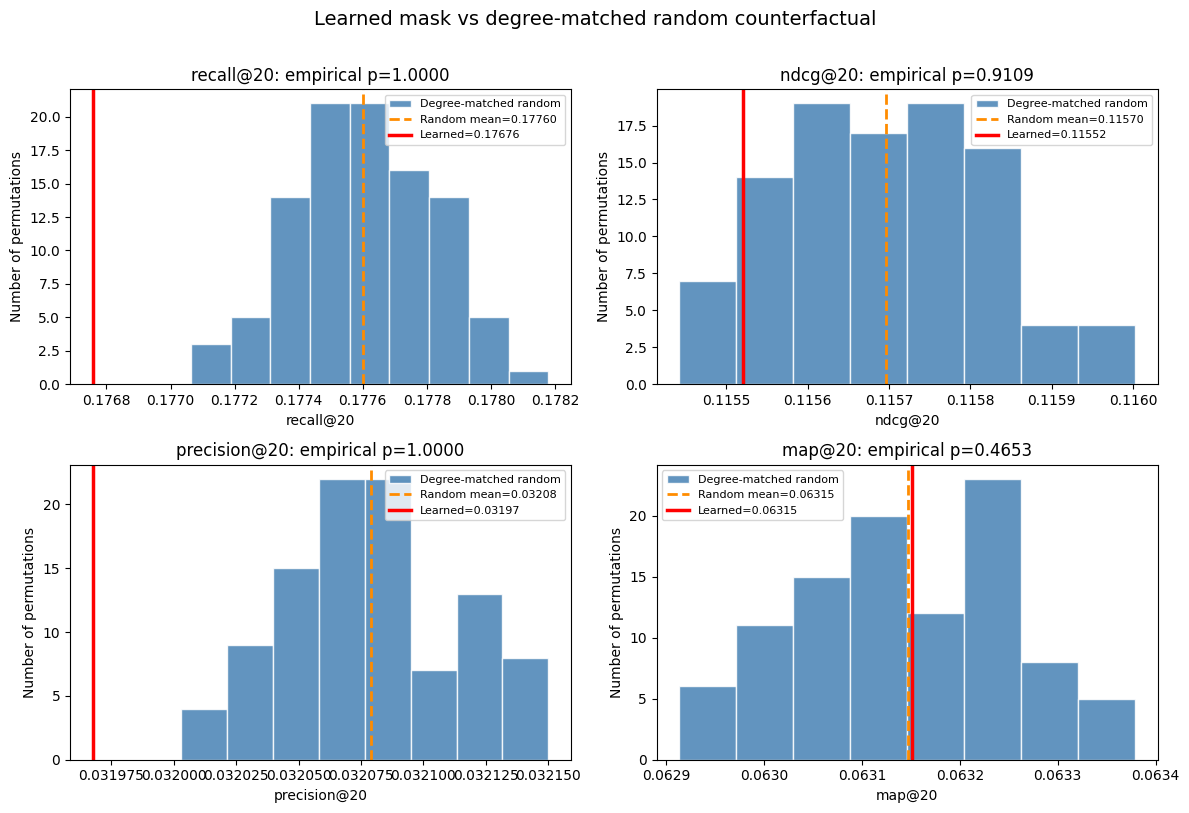

In [28]:
metric_columns = [column for column in random_results.columns if column != "seed"]
summary_rows = []

for metric in metric_columns:
    random_values = random_results[metric].to_numpy(dtype=float)
    learned_value = float(learned_result[metric])
    random_mean = float(random_values.mean())
    random_std = float(random_values.std(ddof=1))
    empirical_p = float(
        (1 + np.sum(random_values >= learned_value))
        / (len(random_values) + 1)
    )

    summary_rows.append({
        "metric": metric,
        "learned": learned_value,
        "random_mean": random_mean,
        "random_std": random_std,
        "random_2.5%": float(np.quantile(random_values, 0.025)),
        "random_97.5%": float(np.quantile(random_values, 0.975)),
        "learned_minus_random": learned_value - random_mean,
        "relative_gain_%": (
            100.0 * (learned_value / random_mean - 1.0)
            if random_mean != 0.0
            else np.nan
        ),
        "fraction_random_at_least_learned": float(
            np.mean(random_values >= learned_value)
        ),
        "empirical_p": empirical_p,
    })

performance_summary = pd.DataFrame(summary_rows).set_index("metric")
display(performance_summary.round(6))
if SAVE_OUTPUTS:
    performance_summary.to_csv(OUTPUT_DIR / "performance_summary.csv")

report_metrics = [
    metric
    for metric in metric_columns
    if metric.endswith(f"@{REPORT_K}")
]
n_columns = 2
n_rows = int(np.ceil(len(report_metrics) / n_columns))
fig, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(12, 4 * n_rows),
)
axes = np.asarray(axes).reshape(-1)

for ax, metric in zip(axes, report_metrics):
    random_values = random_results[metric].to_numpy(dtype=float)
    learned_value = float(learned_result[metric])
    empirical_p = float(performance_summary.loc[metric, "empirical_p"])

    ax.hist(
        random_values,
        bins="auto",
        color="steelblue",
        edgecolor="white",
        alpha=0.85,
        label="Degree-matched random",
    )
    ax.axvline(
        random_values.mean(),
        color="darkorange",
        linestyle="--",
        linewidth=2,
        label=f"Random mean={random_values.mean():.5f}",
    )
    ax.axvline(
        learned_value,
        color="red",
        linewidth=2.5,
        label=f"Learned={learned_value:.5f}",
    )
    ax.set_xlabel(metric)
    ax.set_ylabel("Number of permutations")
    ax.set_title(f"{metric}: empirical p={empirical_p:.4f}")
    ax.legend(fontsize=8)

for ax in axes[len(report_metrics):]:
    ax.remove()

fig.suptitle(
    "Learned mask vs degree-matched random counterfactual",
    fontsize=14,
    y=1.01,
)
fig.tight_layout()
if SAVE_OUTPUTS:
    fig.savefig(OUTPUT_DIR / "performance_permutation_test.png", dpi=200, bbox_inches="tight")
plt.show()

In [29]:
# ================================================================
# PER-USER MEAN MASK ABLATION
# ================================================================

device = learned_logits.device

edge_users_cpu = edge_users.detach().cpu()
learned_mask_cpu = learned_mask.detach().float().cpu()

# Tổng mask và số interaction của từng user.
user_mask_sum = torch.zeros(
    model.n_users,
    dtype=learned_mask_cpu.dtype,
)

user_mask_sum.index_add_(
    0,
    edge_users_cpu,
    learned_mask_cpu,
)

user_edge_count = torch.bincount(
    edge_users_cpu,
    minlength=model.n_users,
).to(learned_mask_cpu.dtype)

active_user = user_edge_count > 0

user_mean_mask = torch.zeros_like(user_mask_sum)

user_mean_mask[active_user] = (
    user_mask_sum[active_user]
    / user_edge_count[active_user]
)

# Mỗi edge nhận mean mask của user tương ứng.
user_mean_edge_mask_cpu = user_mean_mask[
    edge_users_cpu
]

user_mean_edge_mask = user_mean_edge_mask_cpu.to(device)

# Model nhận logits, nên chuyển probability về logits.
epsilon = 1e-7

safe_user_mean_mask = user_mean_edge_mask.clamp(
    min=epsilon,
    max=1.0 - epsilon,
)

user_mean_logits = torch.log(
    safe_user_mean_mask
    / (1.0 - safe_user_mean_mask)
)

print(f"Active users: {active_user.sum().item():,}")
print(f"Edges:        {len(user_mean_edge_mask_cpu):,}")

Active users: 11,000
Edges:        120,464


In [30]:
# Reconstruct mask sau khi chuyển sang logits.
reconstructed_user_mean_mask = (
    torch.sigmoid(user_mean_logits)
    .detach()
    .cpu()
)

collapsed_user_sum = torch.zeros_like(user_mask_sum)

collapsed_user_sum.index_add_(
    0,
    edge_users_cpu,
    reconstructed_user_mean_mask,
)

collapsed_user_mean = torch.zeros_like(user_mean_mask)

collapsed_user_mean[active_user] = (
    collapsed_user_sum[active_user]
    / user_edge_count[active_user]
)

per_user_mean_error = (
    collapsed_user_mean[active_user]
    - user_mean_mask[active_user]
).abs()

effective_degree_error = (
    collapsed_user_sum[active_user]
    - user_mask_sum[active_user]
).abs()

verification = pd.Series({
    "number_active_users": int(active_user.sum()),
    "number_edges": len(edge_users_cpu),
    "max_per_user_mean_error": (
        per_user_mean_error.max().item()
    ),
    "mean_per_user_mean_error": (
        per_user_mean_error.mean().item()
    ),
    "max_effective_degree_error": (
        effective_degree_error.max().item()
    ),
    "mean_effective_degree_error": (
        effective_degree_error.mean().item()
    ),
})

display(verification.to_frame("value"))

,value
number_active_users,1.100000e+04
number_edges,1.204640e+05
max_per_user_mean_error,2.264977e-06
mean_per_user_mean_error,6.687100e-08
max_effective_degree_error,5.187988e-04
mean_effective_degree_error,1.809900e-06


In [31]:
# Learned within-user variance
user_mask_squared_sum = torch.zeros_like(user_mask_sum)

user_mask_squared_sum.index_add_(
    0,
    edge_users_cpu,
    learned_mask_cpu.square(),
)

learned_user_variance = torch.zeros_like(user_mask_sum)

learned_user_variance[active_user] = (
    user_mask_squared_sum[active_user]
    / user_edge_count[active_user]
    - user_mean_mask[active_user].square()
).clamp_min(0)

learned_user_std = learned_user_variance.sqrt()

# Collapsed-mask within-user variance
collapsed_squared_sum = torch.zeros_like(user_mask_sum)

collapsed_squared_sum.index_add_(
    0,
    edge_users_cpu,
    reconstructed_user_mean_mask.square(),
)

collapsed_user_variance = torch.zeros_like(user_mask_sum)

collapsed_user_variance[active_user] = (
    collapsed_squared_sum[active_user]
    / user_edge_count[active_user]
    - collapsed_user_mean[active_user].square()
).clamp_min(0)

collapsed_user_std = collapsed_user_variance.sqrt()

variation_summary = pd.Series({
    "learned_mean_within_user_std": (
        learned_user_std[active_user].mean().item()
    ),
    "learned_median_within_user_std": (
        learned_user_std[active_user].median().item()
    ),
    "collapsed_mean_within_user_std": (
        collapsed_user_std[active_user].mean().item()
    ),
    "collapsed_max_within_user_std": (
        collapsed_user_std[active_user].max().item()
    ),
})

display(variation_summary.to_frame("value"))

,value
learned_mean_within_user_std,0.030235
learned_median_within_user_std,0.012660
collapsed_mean_within_user_std,0.000125
collapsed_max_within_user_std,0.002043


In [32]:
user_mean_attenuation = summarize_attenuation(
    reconstructed_user_mean_mask.to(device),
    "User-mean",
)

user_mean_attenuation_check = learned_attenuation.merge(
    user_mean_attenuation,
    on=["degree_group", "n_edges"],
    suffixes=("_learned", "_usermean"),
)

user_mean_attenuation_check[
    "absolute_mean_drop_error"
] = (
    user_mean_attenuation_check["mean_drop_learned"]
    - user_mean_attenuation_check["mean_drop_usermean"]
).abs()

display(
    user_mean_attenuation_check[
        [
            "degree_group",
            "n_edges",
            "mean_drop_learned",
            "mean_drop_usermean",
            "absolute_mean_drop_error",
        ]
    ]
    .set_index("degree_group")
    .round(10)
)

if (
    user_mean_attenuation_check[
        "absolute_mean_drop_error"
    ].max()
    > 1e-6
):
    raise AssertionError(
        "User-mean mask did not preserve attenuation."
    )

,n_edges,mean_drop_learned,mean_drop_usermean,absolute_mean_drop_error
degree_group,,,,
1-5,14080,0.027288,0.027288,0.000000e+00
6-20,59910,0.039991,0.039991,0.000000e+00
21-50,27144,0.065706,0.065706,0.000000e+00
51+,19330,0.092261,0.092261,1.490000e-08


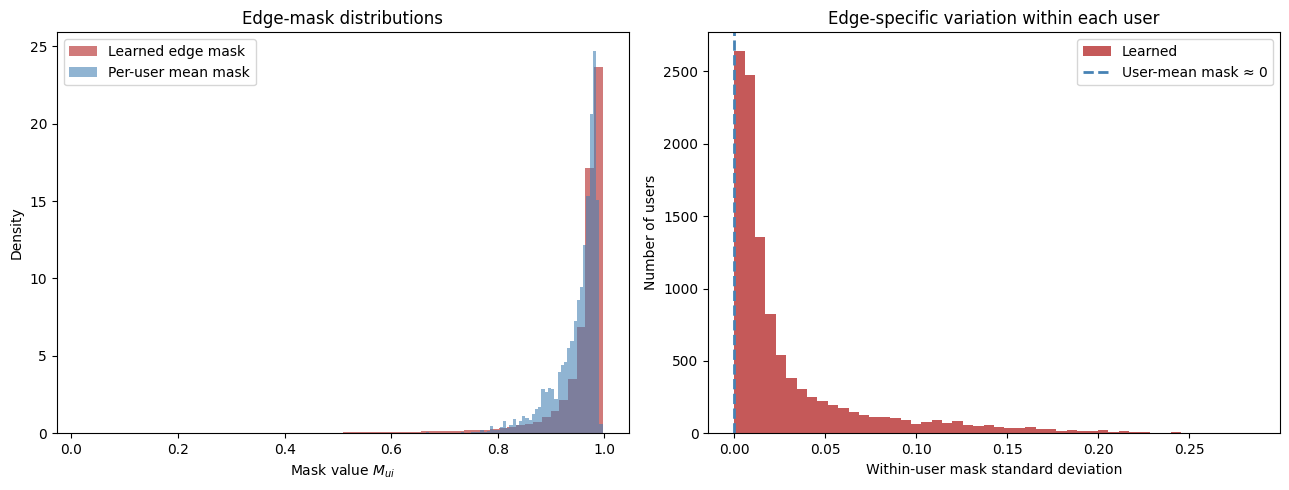

In [33]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

# Edge-level distribution
axes[0].hist(
    learned_mask_cpu.numpy(),
    bins=60,
    density=True,
    alpha=0.60,
    color="firebrick",
    label="Learned edge mask",
)

axes[0].hist(
    reconstructed_user_mean_mask.numpy(),
    bins=60,
    density=True,
    alpha=0.60,
    color="steelblue",
    label="Per-user mean mask",
)

axes[0].set_xlabel(r"Mask value $M_{ui}$")
axes[0].set_ylabel("Density")
axes[0].set_title("Edge-mask distributions")
axes[0].legend()

# Within-user standard deviation
axes[1].hist(
    learned_user_std[active_user].numpy(),
    bins=50,
    alpha=0.75,
    color="firebrick",
    label="Learned",
)

axes[1].axvline(
    collapsed_user_std[active_user].mean().item(),
    color="steelblue",
    linestyle="--",
    linewidth=2,
    label="User-mean mask ≈ 0",
)

axes[1].set_xlabel("Within-user mask standard deviation")
axes[1].set_ylabel("Number of users")
axes[1].set_title("Edge-specific variation within each user")
axes[1].legend()

fig.tight_layout()

if SAVE_OUTPUTS:
    fig.savefig(
        OUTPUT_DIR / "user_mean_mask_distribution.png",
        dpi=200,
        bbox_inches="tight",
    )

plt.show()